# Global Superstore Machine Learning Project

This project analyzes the Global Superstore dataset to extract business insights and build end-to-end machine learning solutions.

The project covers two main machine learning tasks:

1. **Profit Prediction (Regression)**  
   Predict product-line profit using sales, discount, shipping, customer, product, and order-related features.

2. **Customer Segmentation (Clustering)**  
   Segment customers based on purchasing behavior using K-Means clustering.

The workflow includes database integration, exploratory data analysis, feature engineering, model development and evaluation, model persistence, API development, frontend integration, and deployment.

### Technology Stack
- Python
- SQLite
- Pandas & NumPy
- Matplotlib
- Scikit-learn
- FastAPI
- Streamlit
- Vercel
- Streamlit Community Cloud

## Problem Statement & Objectives

Global Superstore operates across multiple markets, product categories, and customer segments. Understanding the factors that influence profitability and identifying meaningful customer groups can support better business decisions.

This project focuses on two machine learning tasks:

### Task 1 — Regression: Profit Prediction
Build a regression model to predict the profit of an individual product line (order item) based on sales, discount, shipping cost, quantity, product category, customer segment, shipping mode, order priority, and market.

### Task 2 — Clustering: Customer Segmentation
Apply K-Means clustering to group customers based on their purchasing behavior, including total spending, order frequency, average order value, and average discount.

The overall objective is to transform product-line data into actionable insights that can support profitability analysis, customer strategy, and data-driven decision making.

## Database Connection & Data Loading

This section connects to the Global Superstore SQLite database and explores its table structure before assembling the working dataset.

### Environment Setup and Database Connection

The required libraries are imported, the provided SQLite database is uploaded to the Colab environment, and a connection is established so the database tables can be queried using SQL.

In [40]:
import sqlite3
import pandas as pd
from google.colab import files

uploaded = files.upload()

conn = sqlite3.connect("superstore.sqlite")

Saving superstore.sqlite to superstore (1).sqlite


In [41]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

print("Available Tables:")
display(tables)

orders = pd.read_sql("""
SELECT *
FROM orders
LIMIT 5;
""", conn)

order_items = pd.read_sql("""
SELECT *
FROM order_items
LIMIT 5;
""", conn)

customers = pd.read_sql("""
SELECT *
FROM dim_customers
LIMIT 5;
""", conn)

products = pd.read_sql("""
SELECT *
FROM dim_products
LIMIT 5;
""", conn)

locations = pd.read_sql("""
SELECT *
FROM dim_locations
LIMIT 5;
""", conn)

print("\nOrders Preview:")
display(orders)

print("\nOrder Items Preview:")
display(order_items)

print("\nCustomers Preview:")
display(customers)

print("\nProducts Preview:")
display(products)

print("\nLocations Preview:")
display(locations)

Available Tables:


,name
0,dim_customers
1,dim_products
2,dim_product_name_variants
3,dim_locations
4,orders
5,order_items



Orders Preview:


,order_key,order_id_raw,customer_id,order_date,ship_date,ship_mode,order_priority,location_id
0,CA-2011-130813_LS-172304,CA-2011-130813,LS-172304,2011-01-07 00:00:00,2011-01-09 00:00:00,Second Class,High,1
1,CA-2011-148614_MV-174854,CA-2011-148614,MV-174854,2011-01-21 00:00:00,2011-01-26 00:00:00,Standard Class,Medium,1
2,CA-2011-118962_CS-121304,CA-2011-118962,CS-121304,2011-08-05 00:00:00,2011-08-09 00:00:00,Standard Class,Medium,1
3,CA-2011-146969_AP-109154,CA-2011-146969,AP-109154,2011-09-29 00:00:00,2011-10-03 00:00:00,Standard Class,High,1
4,CA-2011-117317_JF-154904,CA-2011-117317,JF-154904,2011-10-19 00:00:00,2011-10-19 00:00:00,Same Day,Critical,1



Order Items Preview:


...

,customer_id,customer_name,segment
0,AA-103151,Alex Avila,Consumer
1,AA-103152,Alex Avila,Consumer
2,AA-103153,Alex Avila,Consumer
3,AA-103154,Alex Avila,Consumer
4,AA-103751,Allen Armold,Consumer



Products Preview:


,product_id,category,sub_category,product_name
0,FUR-ADV-10000002,Furniture,Furnishings,"Advantus Photo Frame, Duo Pack"
1,FUR-ADV-10000108,Furniture,Furnishings,"Advantus Clock, Erganomic"
2,FUR-ADV-10000183,Furniture,Furnishings,"Advantus Photo Frame, Black"
3,FUR-ADV-10000188,Furniture,Furnishings,"Advantus Stacking Tray, Erganomic"
4,FUR-ADV-10000190,Furniture,Furnishings,"Advantus Frame, Duo Pack"



Locations Preview:


,location_id,city,state,country,region,market,market2
0,1,Los Angeles,California,United States,West,US,North America
1,2,San Francisco,California,United States,West,US,North America
2,3,San Diego,California,United States,West,US,North America
3,4,Roseville,California,United States,West,US,North America
4,5,Huntington Beach,California,United States,West,US,North America


### Initial Database Inspection

The database contains a normalized structure with separate tables for orders, order items, customers, products, product-name variants, and locations.

The previews show that product-line measures such as sales, profit, quantity, discount, and shipping cost are stored separately from descriptive customer, product, and geographic information. Therefore, multiple tables must be joined to create the complete dataset required for exploratory analysis and machine learning.

### Joining Order Items with Product Information

The `order_items` table contains product-line-level measures such as sales, profit, discount, quantity, and shipping cost, while `dim_products` contains descriptive product information.

Each row in the resulting working dataset represents an individual **product line (order item)** rather than a complete order. Because one order can contain multiple product lines, the final dataset contains more rows than the `orders` table.

In [42]:
items_products = pd.read_sql("""
SELECT
    oi.*,
    p.category,
    p.sub_category,
    p.product_name
FROM order_items AS oi
LEFT JOIN dim_products AS p
    ON oi.product_id = p.product_id
LIMIT 5;
""", conn)

items_products

,row_id,order_key,product_id,discount,quantity,sales,profit,shipping_cost,year,week_num,category,sub_category,product_name
0,1,MX-2014-143658_SC-205753,OFF-LA-10002782,0.0,3,13.0,4.56,1.033,2014,40,Office Supplies,Labels,"Hon File Folder Labels, Adjustable"
1,2,MX-2012-155047_KW-165703,FUR-FU-10004015,0.0,8,252.0,90.72,13.449,2012,42,Furniture,Furnishings,"Tenex Clock, Durable"
2,3,MX-2012-155047_KW-165703,FUR-BO-10002352,0.0,2,193.0,54.08,9.627,2012,42,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Mobile"
3,4,MX-2012-155047_KW-165703,OFF-BI-10004428,0.0,4,35.0,4.96,1.371,2012,42,Office Supplies,Binders,"Cardinal Binder, Clear"
4,5,MX-2012-155047_KW-165703,OFF-AR-10004594,0.0,2,72.0,11.44,3.787,2012,42,Office Supplies,Art,"Sanford Canvas, Water Color"


In [43]:
missing_products = pd.read_sql("""
SELECT COUNT(*) AS missing_product_count
FROM order_items AS oi
LEFT JOIN dim_products AS p
    ON oi.product_id = p.product_id
WHERE p.product_id IS NULL;
""", conn)

missing_products

,missing_product_count
0,0


**Interpretation:**  
All order-item records successfully matched a product record. The missing product count is 0, indicating that the product join does not introduce missing product information.

### Enriching Orders with Customer and Location Information

The `orders` table is joined with the customer and location dimension tables to add descriptive information such as customer segment and geographic details.

In [44]:
orders_details = pd.read_sql("""
SELECT
    o.*,
    c.customer_name,
    c.segment,
    l.city,
    l.state,
    l.country,
    l.region,
    l.market
FROM orders AS o
LEFT JOIN dim_customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN dim_locations AS l
    ON o.location_id = l.location_id
LIMIT 5;
""", conn)

orders_details

,order_key,order_id_raw,customer_id,order_date,ship_date,ship_mode,order_priority,location_id,customer_name,segment,city,state,country,region,market
0,CA-2011-130813_LS-172304,CA-2011-130813,LS-172304,2011-01-07 00:00:00,2011-01-09 00:00:00,Second Class,High,1,Lycoris Saunders,Consumer,Los Angeles,California,United States,West,US
1,CA-2011-148614_MV-174854,CA-2011-148614,MV-174854,2011-01-21 00:00:00,2011-01-26 00:00:00,Standard Class,Medium,1,Mark Van Huff,Consumer,Los Angeles,California,United States,West,US
2,CA-2011-118962_CS-121304,CA-2011-118962,CS-121304,2011-08-05 00:00:00,2011-08-09 00:00:00,Standard Class,Medium,1,Chad Sievert,Consumer,Los Angeles,California,United States,West,US
3,CA-2011-146969_AP-109154,CA-2011-146969,AP-109154,2011-09-29 00:00:00,2011-10-03 00:00:00,Standard Class,High,1,Arthur Prichep,Consumer,Los Angeles,California,United States,West,US
4,CA-2011-117317_JF-154904,CA-2011-117317,JF-154904,2011-10-19 00:00:00,2011-10-19 00:00:00,Same Day,Critical,1,Jeremy Farry,Consumer,Los Angeles,California,United States,West,US


### Checking Join Completeness

The following query checks whether every order has matching customer and location information after the joins.

In [45]:
join_check = pd.read_sql("""
SELECT
    COUNT(*) AS total_orders,
    COUNT(c.customer_id) AS matched_customers,
    COUNT(l.location_id) AS matched_locations
FROM orders AS o
LEFT JOIN dim_customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN dim_locations AS l
    ON o.location_id = l.location_id;
""", conn)

join_check

,total_orders,matched_customers,matched_locations
0,25753,25753,25753


**Interpretation:**  
All 25,753 orders successfully matched both customer and location records. This confirms that the customer and location joins are complete and do not introduce unmatched orders.

### Building the Working Dataset

The product-line data from the `order_items` table is combined with order, customer, product, and location information to create a single dataset for further analysis.

In [46]:
dataset_preview = pd.read_sql("""
SELECT
    oi.*,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.order_priority,
    c.customer_name,
    c.segment,
    p.category,
    p.sub_category,
    p.product_name,
    l.city,
    l.state,
    l.country,
    l.region,
    l.market
FROM order_items AS oi
LEFT JOIN orders AS o
    ON oi.order_key = o.order_key
LEFT JOIN dim_customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN dim_products AS p
    ON oi.product_id = p.product_id
LEFT JOIN dim_locations AS l
    ON o.location_id = l.location_id
LIMIT 5;
""", conn)

dataset_preview

,row_id,order_key,product_id,discount,quantity,sales,profit,shipping_cost,year,week_num,...,customer_name,segment,category,sub_category,product_name,city,state,country,region,market
0,1,MX-2014-143658_SC-205753,OFF-LA-10002782,0.0,3,13.0,4.56,1.033,2014,40,...,Sonia Cooley,Consumer,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",Mexico City,Distrito Federal,Mexico,North,LATAM
1,2,MX-2012-155047_KW-165703,FUR-FU-10004015,0.0,8,252.0,90.72,13.449,2012,42,...,Kelly Williams,Consumer,Furniture,Furnishings,"Tenex Clock, Durable",Dos Quebradas,Risaralda,Colombia,South,LATAM
2,3,MX-2012-155047_KW-165703,FUR-BO-10002352,0.0,2,193.0,54.08,9.627,2012,42,...,Kelly Williams,Consumer,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Mobile",Dos Quebradas,Risaralda,Colombia,South,LATAM
3,4,MX-2012-155047_KW-165703,OFF-BI-10004428,0.0,4,35.0,4.96,1.371,2012,42,...,Kelly Williams,Consumer,Office Supplies,Binders,"Cardinal Binder, Clear",Dos Quebradas,Risaralda,Colombia,South,LATAM
4,5,MX-2012-155047_KW-165703,OFF-AR-10004594,0.0,2,72.0,11.44,3.787,2012,42,...,Kelly Williams,Consumer,Office Supplies,Art,"Sanford Canvas, Water Color",Dos Quebradas,Risaralda,Colombia,South,LATAM


### Creating the Full Working Dataset

After verifying the table relationships using a small preview, the full dataset is created by combining product-line data with order, customer, product, and location information.


In [47]:
dataset = pd.read_sql("""
SELECT
    oi.*,
    o.customer_id,
    o.location_id,
    o.order_date,
    o.ship_date,
    o.ship_mode,
    o.order_priority,
    c.customer_name,
    c.segment,
    p.category,
    p.sub_category,
    p.product_name,
    l.city,
    l.state,
    l.country,
    l.region,
    l.market
FROM order_items AS oi
LEFT JOIN orders AS o
    ON oi.order_key = o.order_key
LEFT JOIN dim_customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN dim_products AS p
    ON oi.product_id = p.product_id
LEFT JOIN dim_locations AS l
    ON o.location_id = l.location_id
""", conn)

print("Dataset shape:", dataset.shape)
display(dataset.head())

Dataset shape: (51290, 26)


,row_id,order_key,product_id,discount,quantity,sales,profit,shipping_cost,year,week_num,...,customer_name,segment,category,sub_category,product_name,city,state,country,region,market
0,1,MX-2014-143658_SC-205753,OFF-LA-10002782,0.0,3,13.0,4.56,1.033,2014,40,...,Sonia Cooley,Consumer,Office Supplies,Labels,"Hon File Folder Labels, Adjustable",Mexico City,Distrito Federal,Mexico,North,LATAM
1,2,MX-2012-155047_KW-165703,FUR-FU-10004015,0.0,8,252.0,90.72,13.449,2012,42,...,Kelly Williams,Consumer,Furniture,Furnishings,"Tenex Clock, Durable",Dos Quebradas,Risaralda,Colombia,South,LATAM
2,3,MX-2012-155047_KW-165703,FUR-BO-10002352,0.0,2,193.0,54.08,9.627,2012,42,...,Kelly Williams,Consumer,Furniture,Bookcases,"Ikea 3-Shelf Cabinet, Mobile",Dos Quebradas,Risaralda,Colombia,South,LATAM
3,4,MX-2012-155047_KW-165703,OFF-BI-10004428,0.0,4,35.0,4.96,1.371,2012,42,...,Kelly Williams,Consumer,Office Supplies,Binders,"Cardinal Binder, Clear",Dos Quebradas,Risaralda,Colombia,South,LATAM
4,5,MX-2012-155047_KW-165703,OFF-AR-10004594,0.0,2,72.0,11.44,3.787,2012,42,...,Kelly Williams,Consumer,Office Supplies,Art,"Sanford Canvas, Water Color",Dos Quebradas,Risaralda,Colombia,South,LATAM


### Working Dataset Summary

The final working dataset contains 51,290 product-line records and 26 features. The joins successfully combine product-line-level measures with order, customer, product, and geographic information.

This dataset will be used as the main source for exploratory data analysis, preprocessing, regression modeling, and customer-level aggregation for clustering.

## Exploratory Data Analysis

This section explores the structure, data types, completeness, and basic characteristics of the working dataset before further preprocessing and modeling.

In [48]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   row_id          51290 non-null  int64  
 1   order_key       51290 non-null  object 
 2   product_id      51290 non-null  object 
 3   discount        51290 non-null  float64
 4   quantity        51290 non-null  int64  
 5   sales           51290 non-null  float64
 6   profit          51290 non-null  float64
 7   shipping_cost   51290 non-null  float64
 8   year            51290 non-null  int64  
 9   week_num        51290 non-null  int64  
 10  customer_id     51290 non-null  object 
 11  location_id     51290 non-null  int64  
 12  order_date      51290 non-null  object 
 13  ship_date       51290 non-null  object 
 14  ship_mode       51290 non-null  object 
 15  order_priority  51290 non-null  object 
 16  customer_name   51290 non-null  object 
 17  segment         51290 non-null 

**Interpretation:**  
The working dataset contains 51,290 rows and 26 columns. All columns contain 51,290 non-null values, indicating that the joined dataset is complete. Numerical variables include discount, quantity, sales, profit, and shipping cost, while the remaining columns contain identifiers, dates, and categorical business information.

### Data Quality Check

Missing values and duplicate records are checked to ensure that the working dataset is complete and does not contain unintentionally repeated observations.

In [49]:
total_missing = dataset.isnull().sum().sum()
duplicate_rows = dataset.duplicated().sum()

print("Total missing values:", total_missing)
print("Duplicate rows:", duplicate_rows)

Total missing values: 0
Duplicate rows: 0


**Interpretation:**  
The dataset contains **0 missing values** and **0 duplicate rows**. Therefore, no missing-value treatment or duplicate removal is required before further analysis.

### Descriptive Statistics

Descriptive statistics are used to summarize the distribution and range of the numerical features in the dataset.

In [50]:
numeric_features = dataset[
    ['discount', 'quantity', 'sales', 'profit', 'shipping_cost']
]

numeric_features.describe()

,discount,quantity,sales,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,3.476545,246.498440,28.610982,26.375818
std,0.212280,2.278766,487.567175,174.340972,57.296810
min,0.000000,1.000000,0.000000,-6599.978000,0.002000
25%,0.000000,2.000000,31.000000,0.000000,2.610000
50%,0.000000,3.000000,85.000000,9.240000,7.790000
75%,0.200000,5.000000,251.000000,36.810000,24.450000
max,0.850000,14.000000,22638.000000,8399.976000,933.570000


**Interpretation:**  
The numerical features show considerable variation across product lines. Sales and shipping cost have maximum values far above their medians, indicating the presence of high-value product lines. Profit ranges from approximately **-6,599.98 to 8,399.98**, showing that the dataset includes both substantial losses and highly profitable product lines. The median discount is 0, while the average discount is approximately 14.3%, indicating that many product lines are completed without a discount.

### Categorical Distribution Summary

The main categorical variables are examined to understand how product lines are distributed across product categories, customer segments, regions, and markets.

In [51]:
print("Category Distribution:")
display(dataset['category'].value_counts())

print("\nCustomer Segment Distribution:")
display(dataset['segment'].value_counts())

print("\nRegion Distribution:")
display(dataset['region'].value_counts())

print("\nMarket Distribution:")
display(dataset['market'].value_counts())

print("\nNumber of Product Categories:", dataset['category'].nunique())

Category Distribution:


,count
category,
Office Supplies,31273
Technology,10141
Furniture,9876



Customer Segment Distribution:


,count
segment,
Consumer,26518
Corporate,15429
Home Office,9343



Region Distribution:


,count
region,
Central,11117
South,6645
EMEA,5029
North,4785
Africa,4587
Oceania,3487
West,3203
Southeast Asia,3129
East,2848



Market Distribution:


,count
market,
APAC,11002
LATAM,10294
EU,10000
US,9994
EMEA,5029
Africa,4587
Canada,384



Number of Product Categories: 3


**Interpretation:**  
Office Supplies is the most frequently purchased product category with **31,273 product-line records**, while Technology and Furniture account for smaller shares. The Consumer segment is the largest customer segment with **26,518 product-line records**, followed by Corporate and Home Office.

Product-line volume also varies across geographic areas. APAC has the largest number of product-line records among markets, followed closely by LATAM, EU, and the US, while Canada has substantially fewer observations. The dataset contains **3 product categories** in total.

### Categorical Feature Distribution

The distribution of product categories and customer segments is visualized to understand the composition of product lines across key categorical features.

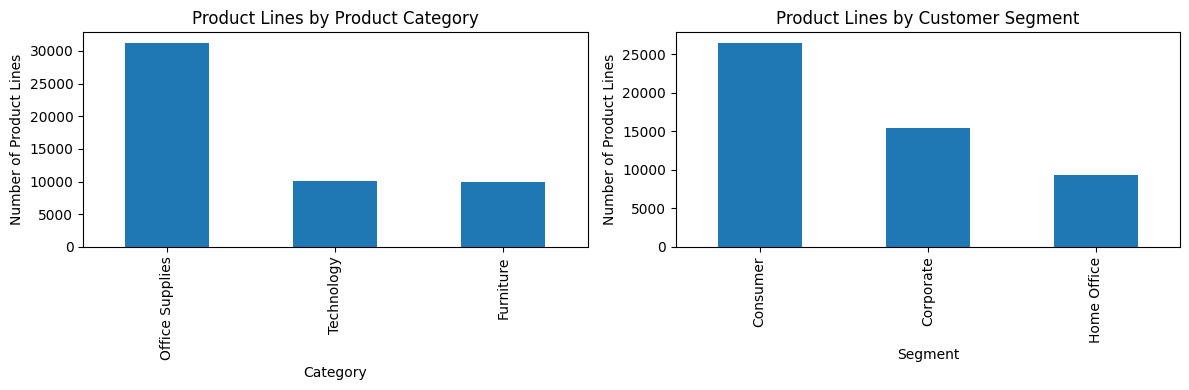

In [52]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dataset['category'].value_counts().plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Product Lines by Product Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Product Lines')

dataset['segment'].value_counts().plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Product Lines by Customer Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Number of Product Lines')

plt.tight_layout()
plt.show()

**Interpretation:**  
The visualization confirms that Office Supplies dominates product-line volume, while the Consumer segment represents the largest share of customers. This imbalance in product-line frequency should be considered when comparing total sales and profit across categories.

### Sales and Profit by Product Category

Product-line frequency alone does not indicate business performance. Therefore, total sales and profit are compared across product categories to understand their financial contribution.

,sales,profit
category,,
Furniture,4110884.0,285204.72380
Office Supplies,3787330.0,518473.83430
Technology,4744691.0,663778.73318


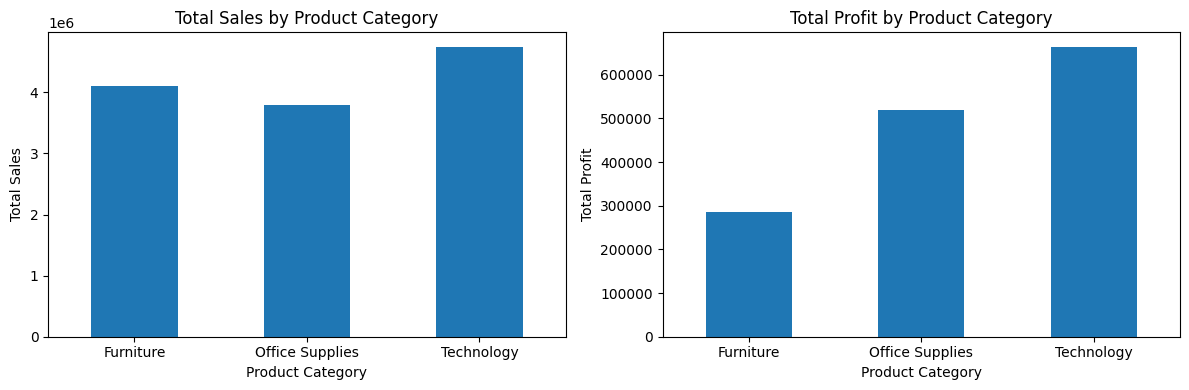

In [53]:
category_performance = dataset.groupby('category')[
    ['sales', 'profit']
].sum()

display(category_performance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

category_performance['sales'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Total Sales by Product Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=0)

category_performance['profit'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Profit by Product Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Interpretation:**  
Technology generates the highest total sales and profit. Office Supplies has the highest product-line volume but produces lower total sales and profit than Technology, showing that product-line frequency alone does not determine financial contribution. Furniture generates substantial sales but considerably lower total profit.

### Profitability by Product Category

To evaluate profitability beyond total sales and profit, the average profit per product line and overall profit margin are compared across product categories.

In [54]:
category_profitability = dataset.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    average_profit=('profit', 'mean'),
    product_line_count=('row_id', 'count')
)

category_profitability['profit_margin_percent'] = (
    category_profitability['total_profit']
    / category_profitability['total_sales']
    * 100
)

display(category_profitability)

,total_sales,total_profit,average_profit,product_line_count,profit_margin_percent
category,,,,,
Furniture,4110884.0,285204.72380,28.878567,9876,6.937795
Office Supplies,3787330.0,518473.83430,16.578961,31273,13.689693
Technology,4744691.0,663778.73318,65.454958,10141,13.989925


**Interpretation:**  
Technology has the highest average profit per product line and the highest profit margin at approximately **13.99%**, closely followed by Office Supplies at **13.69%**. Furniture has a substantially lower profit margin of approximately **6.94%**, motivating further investigation into factors such as discounting.

### Discount and Profit Analysis

Because Furniture shows a substantially lower profit margin than the other product categories, discount levels are examined to determine whether higher discounts may be associated with lower profitability.

In [55]:
discount_by_category = dataset.groupby('category').agg(
    average_discount=('discount', 'mean'),
    average_profit=('profit', 'mean')
)

discount_profit = dataset.groupby('discount').agg(
    average_profit=('profit', 'mean'),
    product_line_count=('row_id', 'count')
)

print("Discount and Profit by Product Category:")
display(discount_by_category)

print("\nProfit by Discount Level:")
display(discount_profit)

Discount and Profit by Product Category:


,average_discount,average_profit
category,,
Furniture,0.168087,28.878567
Office Supplies,0.137409,16.578961
Technology,0.135342,65.454958



Profit by Discount Level:


,average_profit,product_line_count
discount,,
0.000,61.039514,29009
0.002,125.762649,461
0.070,140.990022,150
0.100,63.683426,4068
0.150,50.602409,541
0.170,38.317107,735
0.200,23.552594,4998
0.202,-14.518847,41
0.250,4.043371,198


### Relationship Between Discount and Average Profit

Average profit is compared across discount levels to examine whether profitability changes as discounts increase. Product-line counts are also considered because discount levels with very few observations may produce unstable averages.

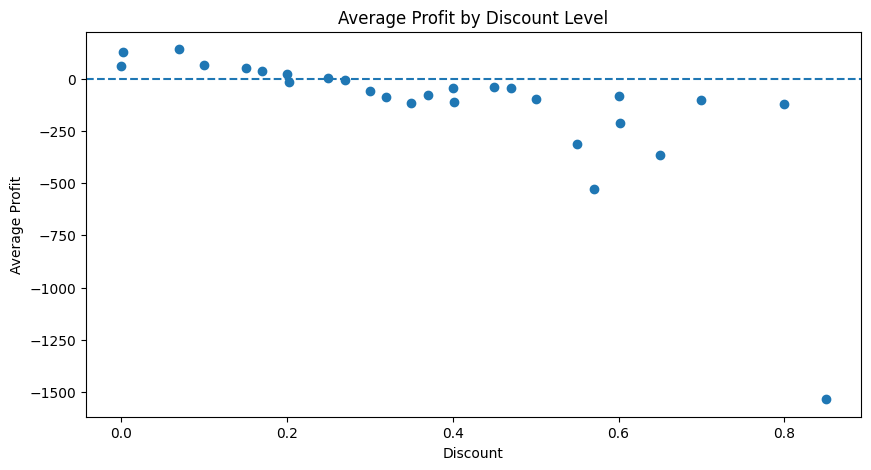

In [56]:
plt.figure(figsize=(10, 5))

plt.scatter(
    discount_profit.index,
    discount_profit['average_profit']
)

plt.axhline(0, linestyle='--')

plt.title('Average Profit by Discount Level')
plt.xlabel('Discount')
plt.ylabel('Average Profit')
plt.show()

#### Product Category Analysis Insight

Technology generates the highest total sales and total profit among the three product categories. Office Supplies records the highest product-line volume but does not generate the highest total profit.

Furniture is notable because its profit margin is approximately 6.94%, substantially lower than Office Supplies and Technology, which both have margins close to 14%. Furniture also has the highest average discount among the three categories.

Further analysis of discount levels shows that higher discounts are generally associated with lower average profit, with many discount levels around 30% and above showing negative average profit. This suggests that discounting may be an important factor related to profitability and should be considered in further analysis and modeling.

### Business Performance by Market

Sales and profit are compared across markets to identify geographic differences in business performance.

,total_sales,total_profit,average_profit,product_line_count,profit_margin_percent
market,,,,,
APAC,3585833.0,436000.04900,39.629163,11002,12.158961
Africa,783776.0,88871.63100,19.374674,4587,11.338907
Canada,66932.0,17817.39000,46.399453,384,26.620137
EMEA,806184.0,43897.97100,8.728966,5029,5.445155
EU,2938139.0,372829.74150,37.282974,10000,12.689316
LATAM,2164687.0,221643.48708,21.531328,10294,10.239055
US,2297354.0,286397.02170,28.656896,9994,12.466386


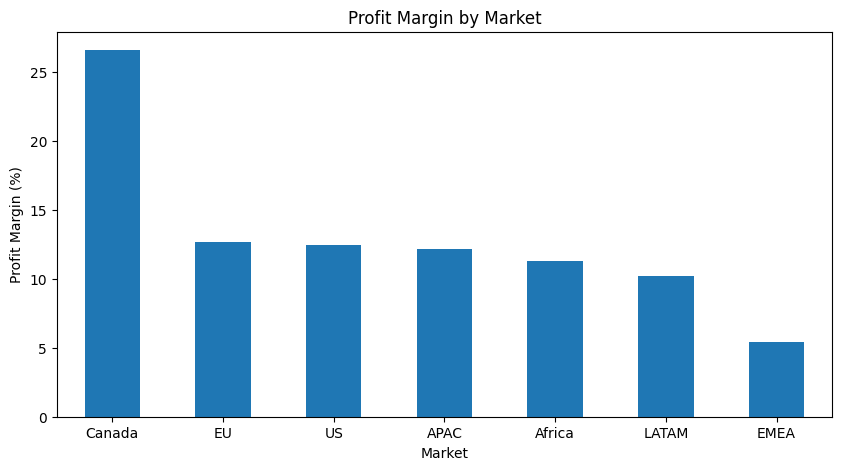

In [57]:
market_performance = dataset.groupby('market').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    average_profit=('profit', 'mean'),
    product_line_count=('row_id', 'count')
)

market_performance['profit_margin_percent'] = (
    market_performance['total_profit']
    / market_performance['total_sales']
    * 100
)

display(market_performance)

plt.figure(figsize=(10, 5))

market_performance['profit_margin_percent'].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Profit Margin by Market')
plt.xlabel('Market')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)
plt.show()

**Interpretation:**  
APAC generates the highest total sales and total profit, while Canada records the highest profit margin at approximately **26.62%**. However, Canada has only **384 product-line records**, so its margin is based on a much smaller product-line volume. EMEA has the lowest profit margin at approximately **5.45%**, which motivates further investigation.

### Investigating Low Profitability in EMEA

EMEA shows the lowest overall profit margin among the markets. To investigate this further, profitability is examined across product categories within the EMEA market.

EMEA product-line count: 5029

EMEA Performance by Category:


,total_sales,total_profit,average_profit,product_line_count,profit_margin_percent
category,,,,,
Furniture,228627.0,11534.136,14.979397,770,5.044958
Office Supplies,276712.0,14869.392,4.509976,3297,5.373599
Technology,300845.0,17494.443,18.185492,962,5.815102



Market-Level Averages:


,average_discount,average_shipping_cost,average_sales,average_profit
market,,,,
APAC,0.148839,35.190430,325.925559,39.629163
Africa,0.156704,19.215058,170.868978,19.374674
Canada,0.000000,19.285495,174.302083,46.399453
EMEA,0.196083,17.573221,160.307019,8.728966
EU,0.103105,30.942235,293.813900,37.282974
LATAM,0.135531,22.744668,210.286283,21.531328
US,0.156203,23.831678,229.873324,28.656896


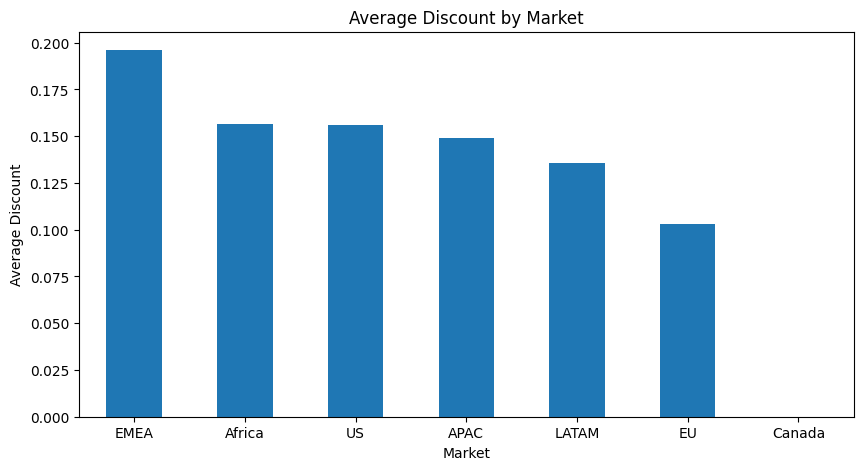

In [58]:
emea_data = dataset[dataset['market'] == 'EMEA']

emea_category = emea_data.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    average_profit=('profit', 'mean'),
    product_line_count=('row_id', 'count')
)

emea_category['profit_margin_percent'] = (
    emea_category['total_profit']
    / emea_category['total_sales']
    * 100
)

market_discount = dataset.groupby('market').agg(
    average_discount=('discount', 'mean'),
    average_shipping_cost=('shipping_cost', 'mean'),
    average_sales=('sales', 'mean'),
    average_profit=('profit', 'mean')
)

print("EMEA product-line count:", emea_data.shape[0])

print("\nEMEA Performance by Category:")
display(emea_category)

print("\nMarket-Level Averages:")
display(market_discount)

plt.figure(figsize=(10, 5))

market_discount['average_discount'].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Average Discount by Market')
plt.xlabel('Market')
plt.ylabel('Average Discount')
plt.xticks(rotation=0)
plt.show()

#### Market Analysis Insight

EMEA has the lowest profit margin among the analyzed markets at approximately 5.45%, despite having more than 5,000 product-line records. Further investigation shows that EMEA also has the highest average discount at approximately 19.6%.

This pattern is consistent with the earlier discount analysis, where higher discount levels were generally associated with lower average profit. However, this relationship should be interpreted as an association rather than direct causation, since profitability may also be influenced by other factors such as product mix, sales value, and shipping costs.

### Sales and Profit Trend Over Time

Yearly sales and profit are analyzed to observe how business performance changes over time.

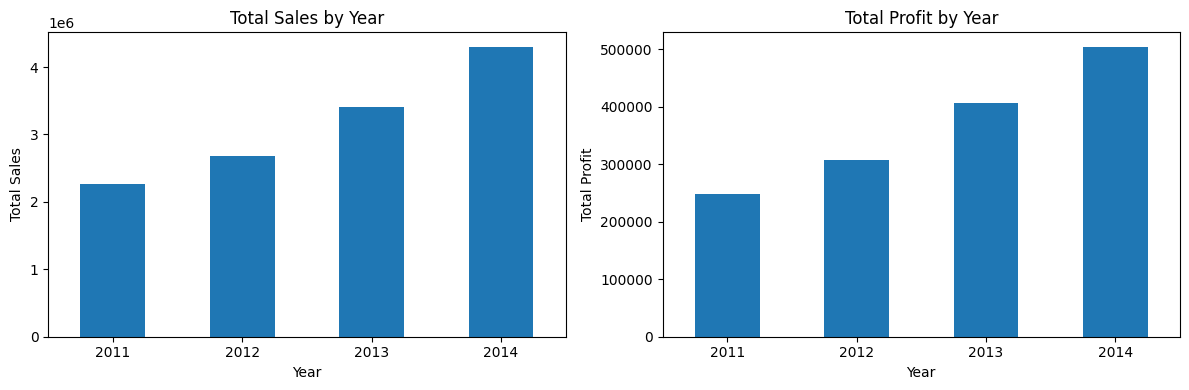

In [59]:
yearly_performance = dataset.groupby('year').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum')
)

yearly_performance

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

yearly_performance['total_sales'].plot(
    kind='bar',
    ax=axes[0]
)
axes[0].set_title('Total Sales by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=0)

yearly_performance['total_profit'].plot(
    kind='bar',
    ax=axes[1]
)
axes[1].set_title('Total Profit by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Profit')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Yearly Performance Insight

Both total sales and total profit increased consistently from 2011 to 2014. The highest sales and profit were recorded in 2014, indicating overall business growth throughout the observed period.

### Correlation Between Numerical Features

Correlation analysis is used to examine the strength and direction of relationships among key numerical features.

,discount,quantity,sales,profit,shipping_cost
discount,1.000000,-0.019875,-0.086728,-0.316490,-0.079055
quantity,-0.019875,1.000000,0.313580,0.104365,0.272649
sales,-0.086728,0.313580,1.000000,0.484923,0.768075
profit,-0.316490,0.104365,0.484923,1.000000,0.354441
shipping_cost,-0.079055,0.272649,0.768075,0.354441,1.000000


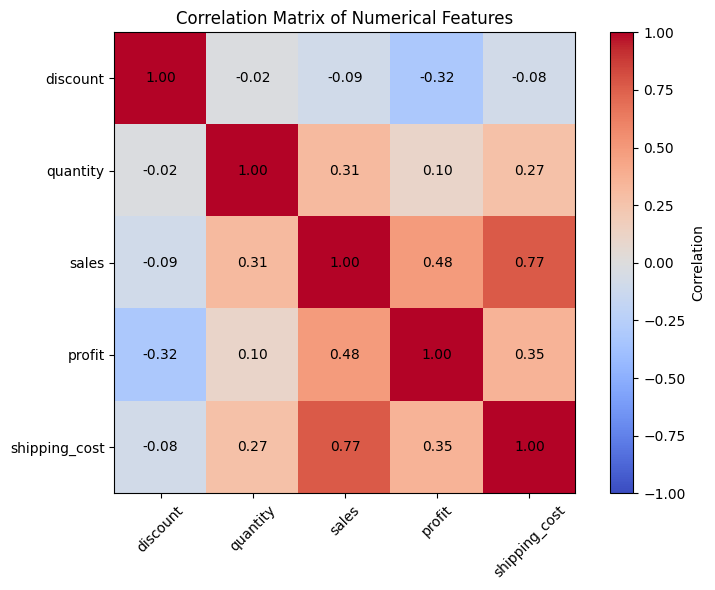

In [60]:
correlation_matrix = dataset[
    ['discount', 'quantity', 'sales', 'profit', 'shipping_cost']
].corr()

display(correlation_matrix)

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f'{correlation_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

#### Correlation Insight

Sales shows a moderate positive correlation with profit, while discount shows a negative correlation with profit. This supports the earlier observation that higher discounts are generally associated with lower profitability.

Sales also has a strong positive correlation with shipping cost, suggesting that higher-value product lines tend to involve higher shipping expenses. However, none of these relationships alone fully explains profit, indicating that profitability is likely influenced by multiple factors.

## Data Preprocessing & Feature Engineering

The dataset is prepared for modeling by correcting data types and creating useful derived features.

### Date Conversion and Shipping Duration

The order and shipping date columns are converted to datetime format. A new feature, `shipping_days`, is then created as the number of days between the order date and ship date to represent delivery duration.

In [61]:
dataset['order_date'] = pd.to_datetime(dataset['order_date'])
dataset['ship_date'] = pd.to_datetime(dataset['ship_date'])

dataset['shipping_days'] = (
    dataset['ship_date'] - dataset['order_date']
).dt.days

print(dataset[['order_date', 'ship_date']].dtypes)
display(
    dataset[
        ['order_date', 'ship_date', 'shipping_days']
    ].head()
)

order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object


,order_date,ship_date,shipping_days
0,2014-10-02,2014-10-06,4
1,2012-10-15,2012-10-20,5
2,2012-10-15,2012-10-20,5
3,2012-10-15,2012-10-20,5
4,2012-10-15,2012-10-20,5


**Interpretation:**  
The date columns are now stored as datetime values, allowing the delivery duration to be calculated correctly. The derived `shipping_days` feature represents the number of days required to ship each order.

### Validating the Shipping Duration Feature

The newly created `shipping_days` feature is checked to ensure that the calculated delivery durations are reasonable and do not contain invalid negative values.

In [62]:
shipping_summary = dataset['shipping_days'].describe()
negative_shipping_days = (
    dataset['shipping_days'] < 0
).sum()

print("Shipping Duration Summary:")
display(shipping_summary)

print(
    "\nNegative shipping durations:",
    negative_shipping_days
)

print("\nShipping Duration Distribution:")
display(
    dataset['shipping_days']
    .value_counts()
    .sort_index()
)

Shipping Duration Summary:


,shipping_days
count,51290.000000
mean,3.969370
std,1.729437
min,0.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,7.000000



Negative shipping durations: 0

Shipping Duration Distribution:


,count
shipping_days,
0,2600
1,1662
2,7026
3,5035
4,14434
5,11221
6,6255
7,3057


**Interpretation:**  
Shipping duration ranges from **0 to 7 days**, with an average of approximately **3.97 days** and a median of **4 days**. No negative shipping durations are present, indicating that the derived feature is valid.

### Feature Selection and Target Definition

For the regression task, `profit` is selected as the target variable. The input features include product-line measures, product characteristics, customer segment, shipping, and market information that may be associated with profitability. Identifier columns and high-cardinality names are excluded because they do not represent meaningful generalizable characteristics for prediction.
Although `shipping_days` was created for exploratory and business analysis, it is not included in the final regression input. The feature requires `ship_date`, which may not yet be available when the profit of a new product line needs to be predicted. Excluding it makes the production model more practical and avoids relying on future information.

In [63]:
regression_features = [
    'discount',
    'quantity',
    'sales',
    'shipping_cost',
    'category',
    'segment',
    'ship_mode',
    'order_priority',
    'market'
]

X = dataset[regression_features]
y = dataset['profit']

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (51290, 9)
y shape: (51290,)


,discount,quantity,sales,shipping_cost,category,segment,ship_mode,order_priority,market
0,0.0,3,13.0,1.033,Office Supplies,Consumer,Standard Class,Medium,LATAM
1,0.0,8,252.0,13.449,Furniture,Consumer,Standard Class,Medium,LATAM
2,0.0,2,193.0,9.627,Furniture,Consumer,Standard Class,Medium,LATAM
3,0.0,4,35.0,1.371,Office Supplies,Consumer,Standard Class,Medium,LATAM
4,0.0,2,72.0,3.787,Office Supplies,Consumer,Standard Class,Medium,LATAM


**Interpretation:**  
The regression dataset contains **51,290 observations and 9 input features**, while `profit` is used as the continuous target variable.

### Train-Test Split

The dataset is divided into training and testing sets using an 80:20 split. A fixed `random_state=42` is used to make the split reproducible.

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 41032
Testing rows: 10258


**Interpretation:**  
The split produces **41,032 training observations** and **10,258 testing observations**. The training data is used to fit the models, while the unseen testing data is reserved for evaluation.

### Categorical Feature Encoding

Machine learning models require numerical input. Therefore, categorical variables are converted into one-hot encoded features. The test set is reindexed to match the training columns so both datasets have an identical feature structure.

In [65]:
categorical_cols = [
    'category',
    'segment',
    'ship_mode',
    'order_priority',
    'market'
]

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_cols
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_cols
)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Before encoding:", X_train.shape)
print("After encoding:", X_train_encoded.shape)

display(X_train_encoded.head())

Before encoding: (41032, 9)
After encoding: (41032, 25)


,discount,quantity,sales,shipping_cost,category_Furniture,category_Office Supplies,category_Technology,segment_Consumer,segment_Corporate,segment_Home Office,...,order_priority_High,order_priority_Low,order_priority_Medium,market_APAC,market_Africa,market_Canada,market_EMEA,market_EU,market_LATAM,market_US
2558,0.0,3,90.0,6.183,True,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
15041,0.5,2,47.0,3.310,False,True,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
38072,0.2,3,93.0,9.130,False,True,False,True,False,False,...,False,False,True,False,False,False,False,False,False,True
15694,0.0,4,197.0,31.720,False,True,False,False,True,False,...,True,False,False,False,False,False,False,True,False,False
30044,0.1,8,353.0,34.770,False,True,False,True,False,False,...,False,False,True,True,False,False,False,False,False,False


**Interpretation:**  
One-hot encoding expands the original categorical variables into separate binary columns while preserving the numerical features. The training and testing datasets now contain the same encoded feature columns.

### Feature Scaling

The encoded features are standardized using `StandardScaler`. The scaler is fitted only on the training data to prevent information from the test set from leaking into the training process.

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_encoded
)

X_test_scaled = scaler.transform(
    X_test_encoded
)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

print(
    "First five training feature means:",
    X_train_scaled.mean(axis=0)[:5]
)

Training shape: (41032, 25)
Testing shape: (10258, 25)
First five training feature means: [-2.01524203e-17 -1.29875963e-17  1.54768856e-17 -3.01312234e-17
 -3.96771067e-17]


**Interpretation:**  
The encoded features are standardized using statistics learned only from the training data. The transformed training features have means close to zero, confirming that scaling was applied correctly. Scaling is required for the Linear Regression baseline used below, while the later Random Forest model does not depend on feature scaling.

## Modelling Task 1 — Regression: Profit Prediction
Linear Regression is used as the baseline regression model to predict product-line profit. The model is trained using the preprocessed training features and evaluated on unseen test data.

In [67]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

LinearRegression()

### Generating Predictions

The trained model is used to predict profit values for the test dataset, which contains observations that were not used during model training.

In [68]:
y_pred = linear_model.predict(X_test_scaled)

### Regression Model Evaluation

The model is evaluated using MAE, RMSE, and R², as required for the regression task. These metrics provide different perspectives on prediction error and overall model performance.

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 58.578963188619234
RMSE: 138.6885774915558
R²: 0.3570036002765701


#### Baseline Regression Result

The Linear Regression model achieved an MAE of approximately 58.58, an RMSE of 138.69, and an R² score of 0.357.

The model explains approximately 35.7% of the variation in product-line profit. The RMSE is substantially higher than the MAE, indicating that some product lines produce relatively large prediction errors. This is consistent with the earlier exploratory analysis, which showed extreme profit values and a wide profit distribution.

Therefore, Linear Regression provides a useful baseline, but a more flexible model may be needed to capture nonlinear patterns in profitability.

### Random Forest Regression

A Random Forest Regressor is trained as a more flexible alternative to the Linear Regression baseline. Random Forest can capture nonlinear relationships and interactions between features.

In [70]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

rf_pred = rf_model.predict(X_test_encoded)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

model_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'RMSE': [rmse, rf_rmse],
    'R²': [r2, rf_r2]
})

print("\nModel Comparison:")
display(model_comparison)

Random Forest MAE: 34.575574271712206
Random Forest RMSE: 86.61842434883317
Random Forest R²: 0.7491883458019956

Model Comparison:


,Model,MAE,RMSE,R²
0,Linear Regression,58.578963,138.688577,0.357004
1,Random Forest,34.575574,86.618424,0.749188


#### Random Forest Regression Result

The Random Forest Regressor substantially outperformed the Linear Regression baseline.

The model achieved an MAE of approximately 34.58, an RMSE of 86.62, and an R² score of 0.749. Compared with Linear Regression, both MAE and RMSE decreased considerably, while R² increased from approximately 0.357 to 0.749.

These results suggest that the relationships between product-line characteristics and profit contain nonlinear patterns that are better captured by Random Forest.

### Feature Importance

Feature importance from the Random Forest model is examined to identify which input features contribute most to profit prediction.

,feature,importance
2,sales,0.536508
0,discount,0.289196
3,shipping_cost,0.055106
1,quantity,0.032734
16,order_priority_Low,0.009132
18,market_APAC,0.006112
7,segment_Consumer,0.005893
12,ship_mode_Second Class,0.005469
8,segment_Corporate,0.005395
4,category_Furniture,0.005272


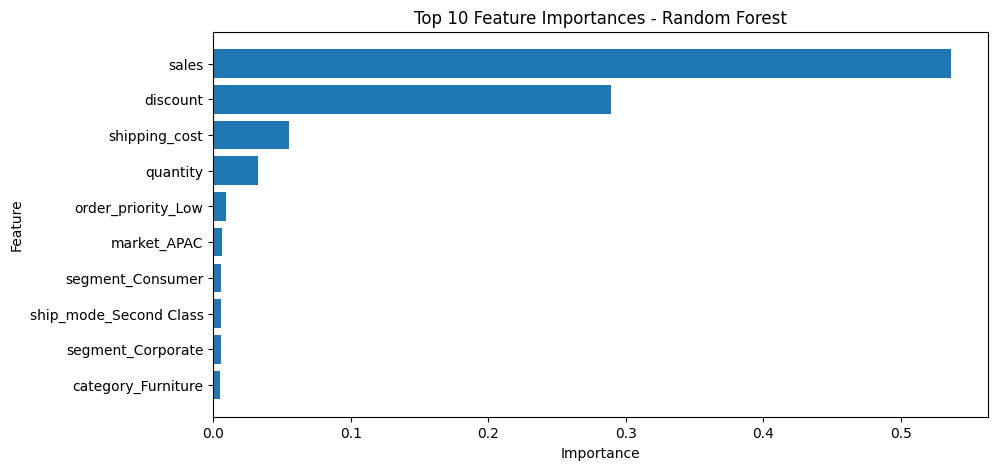

In [71]:
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

top_features = feature_importance.head(10)

display(top_features)

plt.figure(figsize=(10, 5))

plt.barh(
    top_features['feature'],
    top_features['importance']
)

plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

#### Feature Importance Insight

Sales is the most influential feature in the Random Forest model, followed by discount. Together, these two features account for most of the model's feature importance.

This result is consistent with the exploratory analysis, where sales showed a positive relationship with profit while higher discount levels were generally associated with lower profitability.

Shipping cost and quantity provide additional predictive information, while individual categorical features contribute relatively smaller amounts. Feature importance represents how useful a feature is for prediction and does not by itself indicate the direction or causality of its relationship with profit.

#### Regression Model Selection

Random Forest was selected as the stronger regression model because it substantially outperformed the Linear Regression baseline across all evaluation metrics.

Linear Regression achieved an MAE of approximately 58.58, RMSE of 138.69, and R² of 0.357, while Random Forest achieved an MAE of approximately 34.58, RMSE of 86.62, and R² of 0.749.

The improvement suggests that product-line profitability contains nonlinear relationships and feature interactions that are better captured by Random Forest.

## Modelling Task 2 — Clustering: Customer Segmentation

Customer-level features are created from product-line data to identify natural groups based on purchasing behaviour. Unlike regression, clustering is an unsupervised learning task and therefore does not use a target variable or a train/test split.

### Customer-Level Feature Engineering

Because the working dataset contains product-line-level records, the data is aggregated by customer before clustering. Each customer is represented using purchasing behavior such as total spending, order frequency, average order value, and average discount.

These variables are selected because they capture both customer value and purchasing behavior without using predefined labels.

In [72]:
from sklearn.preprocessing import StandardScaler

customer_data = dataset.groupby('customer_id').agg(
    total_spending=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('order_key', 'nunique'),
    total_quantity=('quantity', 'sum'),
    average_discount=('discount', 'mean')
).reset_index()

customer_data['average_order_value'] = (
    customer_data['total_spending']
    / customer_data['order_count']
)

clustering_features = [
    'total_spending',
    'order_count',
    'average_order_value',
    'average_discount'
]

X_cluster = customer_data[clustering_features]

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster
)

print("Customer-level dataset shape:", customer_data.shape)
print("Clustering feature shape:", X_cluster.shape)

print(
    "Scaled feature means:",
    X_cluster_scaled.mean(axis=0)
)

display(customer_data.head())

Customer-level dataset shape: (4873, 7)
Clustering feature shape: (4873, 4)
Scaled feature means: [ 1.31230959e-17  6.88962534e-17 -7.07189056e-17 -9.47779147e-17]


,customer_id,total_spending,total_profit,order_count,total_quantity,average_discount,average_order_value
0,AA-103151,1445.0,12.8760,5,44,0.270000,289.000000
1,AA-103152,6105.0,568.7370,7,50,0.040625,872.142857
2,AA-103153,633.0,228.9600,2,21,0.000000,316.500000
3,AA-103154,5565.0,-362.8825,5,30,0.090909,1113.000000
4,AA-103751,2407.0,577.9350,4,35,0.066667,601.750000


**Interpretation:**  
The product-line data is aggregated into **4,873 unique customers**. Four behavioral features are used for clustering: total spending, order count, average order value, and average discount.

Standardization is applied because these variables use different numerical scales. The scaled feature means are approximately zero, confirming that the features have been standardized successfully.

### Determining the Number of Clusters

The number of clusters is evaluated using both the **Elbow Method** and the **Silhouette Score**. The Elbow Method measures how much within-cluster variation decreases as more clusters are added, while the Silhouette Score measures how well separated the resulting clusters are.

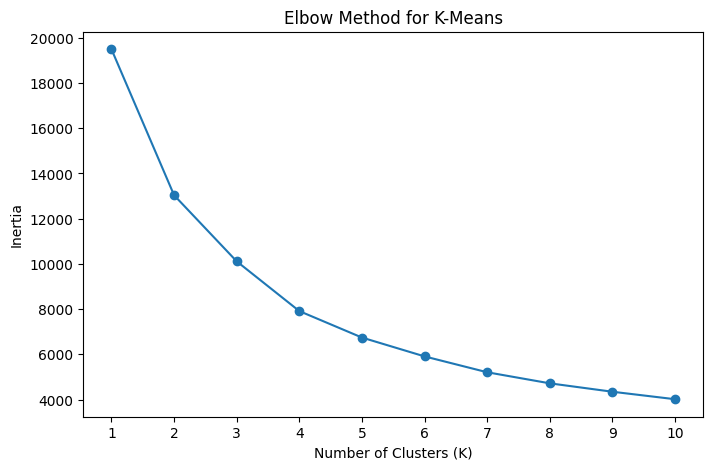

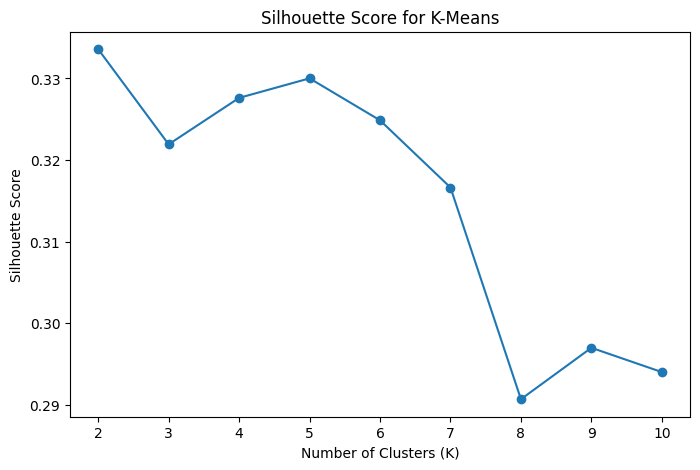

K=2: 0.3336
K=3: 0.3219
K=4: 0.3276
K=5: 0.3300
K=6: 0.3249
K=7: 0.3166
K=8: 0.2907
K=9: 0.2970
K=10: 0.2940


In [73]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow Method
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(
    k_values,
    inertias,
    marker='o'
)
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.show()


# Silhouette Score
silhouette_scores = []
k_values_silhouette = range(2, 11)

for k in k_values_silhouette:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_cluster_scaled
    )

    score = silhouette_score(
        X_cluster_scaled,
        labels
    )

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(
    k_values_silhouette,
    silhouette_scores,
    marker='o'
)
plt.title('Silhouette Score for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values_silhouette)
plt.show()

for k, score in zip(
    k_values_silhouette,
    silhouette_scores
):
    print(f"K={k}: {score:.4f}")

#### Cluster Count Selection

The Silhouette Score is highest at **K = 2 (0.3336)**. However, **K = 5 also achieves a very similar score of 0.3300**, indicating that the additional clusters do not substantially reduce cluster separation.

The Elbow Method shows diminishing improvements around **K = 4–5**. Since the objective of this analysis is customer segmentation for business use, **K = 5** is selected because it provides more detailed and actionable customer groups while maintaining a Silhouette Score close to the maximum.

Therefore, the final choice of K is based on a balance between statistical quality and business interpretability rather than the Silhouette Score alone.

### Final K-Means Clustering

The final K-Means model is trained using **K = 5** based on the evaluation above. The resulting cluster assignments are then profiled using customer spending, profitability, purchase frequency, quantity, discount usage, and average order value.

In [74]:
final_kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_data['cluster'] = final_kmeans.fit_predict(
    X_cluster_scaled
)

cluster_profile = customer_data.groupby('cluster').agg(
    customer_count=('customer_id', 'count'),
    avg_spending=('total_spending', 'mean'),
    avg_profit=('total_profit', 'mean'),
    avg_orders=('order_count', 'mean'),
    avg_quantity=('total_quantity', 'mean'),
    avg_discount=('average_discount', 'mean'),
    avg_order_value=('average_order_value', 'mean')
)

print("Cluster Sizes:")
display(
    customer_data['cluster']
    .value_counts()
    .sort_index()
)

print("\nCluster Profile:")
display(cluster_profile)

Cluster Sizes:


,count
cluster,
0,422
1,1662
2,1561
3,698
4,530



Cluster Profile:


,customer_count,avg_spending,avg_profit,avg_orders,avg_quantity,avg_discount,avg_order_value
cluster,,,,,,,
0,422,4903.824645,753.421124,4.052133,38.815166,0.096145,1271.172788
1,1662,2885.484958,295.830164,7.179904,49.525271,0.142615,418.429073
2,1561,825.976938,154.190135,3.003844,15.516976,0.049754,274.277235
3,698,816.361032,-178.763900,3.389685,17.650430,0.389542,232.172186
4,530,7393.669811,1022.509897,9.537736,81.281132,0.123931,802.620129


**Interpretation:**  
The five clusters differ clearly in customer value, purchasing frequency, order size, and discount behavior.

Cluster 4 has the highest average spending, profit, order frequency, and quantity, while Cluster 0 has the highest average order value. Cluster 3 is distinctive because it receives the highest average discount and produces negative average profit. These differences provide a basis for assigning meaningful business labels to each cluster.

### Cluster Interpretation and Labeling

The five clusters are interpreted based on their purchasing behavior, profitability, order frequency, and discount usage. Descriptive labels are assigned to make the segmentation easier to understand from a business perspective.

,customer_count,avg_spending,avg_profit,avg_orders,avg_discount,avg_order_value
segment_label,,,,,,
Frequent Regular Customers,1662,2885.484958,295.830164,7.179904,0.142615,418.429073
High-Discount Unprofitable Customers,698,816.361032,-178.763900,3.389685,0.389542,232.172186
High-Ticket Customers,422,4903.824645,753.421124,4.052133,0.096145,1271.172788
High-Value Frequent Customers,530,7393.669811,1022.509897,9.537736,0.123931,802.620129
Low-Value Occasional Customers,1561,825.976938,154.190135,3.003844,0.049754,274.277235


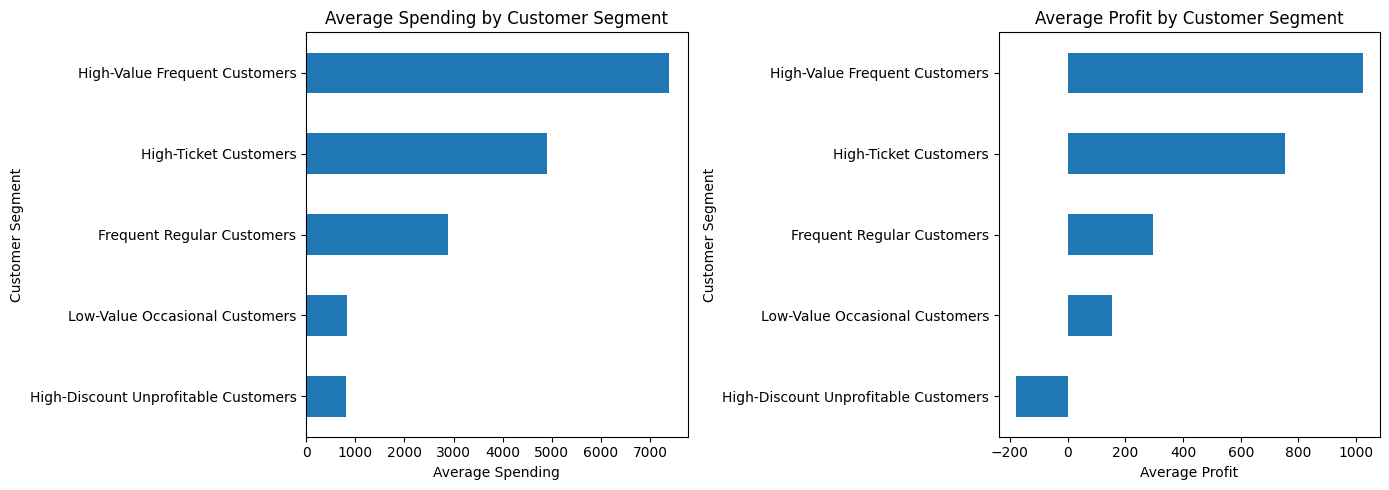

In [75]:
cluster_labels = {
    0: 'High-Ticket Customers',
    1: 'Frequent Regular Customers',
    2: 'Low-Value Occasional Customers',
    3: 'High-Discount Unprofitable Customers',
    4: 'High-Value Frequent Customers'
}

customer_data['segment_label'] = customer_data['cluster'].map(
    cluster_labels
)

cluster_summary = customer_data.groupby('segment_label').agg(
    customer_count=('customer_id', 'count'),
    avg_spending=('total_spending', 'mean'),
    avg_profit=('total_profit', 'mean'),
    avg_orders=('order_count', 'mean'),
    avg_discount=('average_discount', 'mean'),
    avg_order_value=('average_order_value', 'mean')
)

display(cluster_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_summary['avg_spending'].sort_values().plot(
    kind='barh',
    ax=axes[0]
)
axes[0].set_title('Average Spending by Customer Segment')
axes[0].set_xlabel('Average Spending')
axes[0].set_ylabel('Customer Segment')

cluster_summary['avg_profit'].sort_values().plot(
    kind='barh',
    ax=axes[1]
)
axes[1].set_title('Average Profit by Customer Segment')
axes[1].set_xlabel('Average Profit')
axes[1].set_ylabel('Customer Segment')

plt.tight_layout()
plt.show()

#### Customer Segmentation Insight

K-Means clustering identified five distinct customer segments.

- **High-Value Frequent Customers** show the highest average spending, profit, order frequency, and purchase quantity, making them the most valuable customer group.
- **High-Ticket Customers** purchase less frequently but have the highest average order value, indicating large purchases per order.
- **Frequent Regular Customers** place orders relatively often with moderate spending and profitability.
- **Low-Value Occasional Customers** have relatively low spending, order frequency, and average order value.
- **High-Discount Unprofitable Customers** receive substantially higher average discounts and generate negative average profit, suggesting that discount strategies for this segment may require closer review.

The clustering results are also consistent with the earlier exploratory analysis, where higher discount levels were generally associated with lower profitability.

#### Business Recommendations by Customer Segment

- **High-Value Frequent Customers:** prioritize retention through loyalty rewards, personalized offers, and premium customer experiences.
- **High-Ticket Customers:** encourage repeat purchases through targeted follow-up campaigns and complementary product recommendations.
- **Frequent Regular Customers:** use cross-selling, bundles, and loyalty incentives to increase average order value.
- **Low-Value Occasional Customers:** use low-cost re-engagement strategies and targeted promotions to encourage repeat purchases.
- **High-Discount Unprofitable Customers:** review discount eligibility and promotional strategies to reduce the risk of generating unprofitable product lines.

## Production Pipelines & Model Persistence

The final regression and clustering workflows are packaged into reusable Scikit-learn pipelines so that preprocessing and prediction can be performed consistently during deployment.

The trained pipelines and cluster-label mapping are then saved using Joblib. This allows the backend API to load the trained artifacts directly without retraining the models.

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

numeric_features = [
    'discount',
    'quantity',
    'sales',
    'shipping_cost'
]

categorical_features = [
    'category',
    'segment',
    'ship_mode',
    'order_priority',
    'market'
]

regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_features
        ),
        (
            'numerical',
            'passthrough',
            numeric_features
        )
    ]
)

regression_pipeline = Pipeline(
    steps=[
        ('preprocessor', regression_preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

regression_pipeline.fit(X_train, y_train)

pipeline_pred = regression_pipeline.predict(X_test)

pipeline_mae = mean_absolute_error(
    y_test,
    pipeline_pred
)

pipeline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pipeline_pred
    )
)

pipeline_r2 = r2_score(
    y_test,
    pipeline_pred
)

print("Pipeline MAE:", pipeline_mae)
print("Pipeline RMSE:", pipeline_rmse)
print("Pipeline R²:", pipeline_r2)

Pipeline MAE: 34.61514050797125
Pipeline RMSE: 87.30826762748596
Pipeline R²: 0.7451774273893397


**Interpretation:**  
The production regression pipeline achieves an MAE of approximately **34.62**, RMSE of **87.31**, and R² of **0.745** on the test data.

These results are consistent with the previously evaluated Random Forest model, confirming that the preprocessing and model steps have been packaged successfully without materially changing predictive performance.

### Clustering Production Pipeline

The fitted scaler and K-Means model are combined into a single pipeline so that new customer data can be standardized and assigned to a cluster using the same preprocessing steps applied during model development.

In [77]:
clustering_pipeline = Pipeline(
    steps=[
        ('scaler', cluster_scaler),
        ('model', final_kmeans)
    ]
)

pipeline_cluster_pred = clustering_pipeline.predict(
    X_cluster.head()
)

print("Pipeline prediction:")
print(pipeline_cluster_pred)

print("Original cluster:")
print(
    customer_data['cluster']
    .head()
    .to_numpy()
)

Pipeline prediction:
[3 4 2 0 2]
Original cluster:
[3 4 2 0 2]


**Interpretation:**  
The clustering pipeline reproduces the same cluster assignments as the original fitted K-Means workflow. This confirms that the scaler and clustering model are packaged correctly for deployment.

### Model Persistence Verification

The final regression pipeline, clustering pipeline, and cluster-label mapping are saved using Joblib. The saved artifacts are then loaded again and tested to confirm that they can be reused by the backend without retraining.

In [78]:
import joblib

joblib.dump(
    regression_pipeline,
    'regression_pipeline.pkl'
)

joblib.dump(
    clustering_pipeline,
    'clustering_pipeline.pkl'
)

joblib.dump(
    cluster_labels,
    'cluster_labels.pkl'
)

loaded_regression = joblib.load(
    'regression_pipeline.pkl'
)

loaded_clustering = joblib.load(
    'clustering_pipeline.pkl'
)

loaded_labels = joblib.load(
    'cluster_labels.pkl'
)

test_regression_input = X_test.iloc[[0]]

original_prediction = regression_pipeline.predict(
    test_regression_input
)

loaded_prediction = loaded_regression.predict(
    test_regression_input
)

test_cluster_input = X_cluster.iloc[[0]]

cluster_number = loaded_clustering.predict(
    test_cluster_input
)[0]

print("Regression prediction before saving:")
print(original_prediction)

print("\nRegression prediction after loading:")
print(loaded_prediction)

print("\nLoaded clustering prediction:")
print("Cluster:", cluster_number)
print("Label:", loaded_labels[cluster_number])

Regression prediction before saving:
[179.807107]

Regression prediction after loading:
[179.807107]

Loaded clustering prediction:
Cluster: 3
Label: High-Discount Unprofitable Customers


**Interpretation:**  
The regression prediction remains identical before and after saving and loading, confirming that serialization preserves model behavior. The loaded clustering pipeline also produces a valid cluster assignment and corresponding business label.

For deployment, the regression model file stored in the GitHub repository uses **LZ4 compression** to reduce its file size. This compression only changes how the trained model is stored and does not retrain or alter its predictions.

## Conclusion & Business Insights

This project successfully developed an end-to-end machine learning workflow using the Global Superstore dataset, covering data integration, exploratory analysis, regression, customer segmentation, model persistence, API development, frontend integration, and deployment.

### Business Insights

The exploratory analysis showed several important patterns:

- Technology generated the highest total profit among product categories.
- Furniture had a noticeably lower profit margin compared with Technology and Office Supplies.
- Higher discount levels were generally associated with lower profitability, with several high-discount groups producing negative average profit.
- APAC generated the highest total profit among markets, while Canada showed a high profit margin despite having a much smaller number of product-line records.
- Sales and profit increased over the observed yearly period.
- Discount showed a negative relationship with profit, while sales showed a positive relationship with profit.

### Regression Result

Two regression approaches were evaluated:

- Linear Regression
- Random Forest Regression

Random Forest produced the stronger performance and was selected as the final regression model.

Final Random Forest pipeline performance:

- **MAE:** 34.62
- **RMSE:** 87.31
- **R²:** 0.745

The result indicates that the model explains approximately 74.5% of the variation in product-line profit on the test data.

### Customer Segmentation

K-Means clustering was used to segment customers based on:

- Total spending
- Order frequency
- Average order value
- Average discount

After evaluating the elbow method and silhouette scores, **K = 5** was selected to provide more detailed and actionable customer segments.

The resulting segments were:

1. High-Ticket Customers
2. Frequent Regular Customers
3. Low-Value Occasional Customers
4. High-Discount Unprofitable Customers
5. High-Value Frequent Customers

These segments can support different strategies such as customer retention, cross-selling, re-engagement, and discount optimization.

### Deployment

The trained models were saved and integrated into a production pipeline.

The final application uses:

- **FastAPI** for the machine learning API
- **Streamlit** for the user interface
- **Vercel** for backend deployment
- **Streamlit Community Cloud** for frontend deployment

Both the profit prediction and customer segmentation features were successfully tested through the deployed application.